In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('./dataset/Predict Hair Fall.csv')
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,148393,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,155074,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,118261,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,111915,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [3]:
print(df.isnull().sum())

Id                           0
Genetics                     0
Hormonal Changes             0
Medical Conditions           0
Medications & Treatments     0
Nutritional Deficiencies     0
Stress                       0
Age                          0
Poor Hair Care Habits        0
Environmental Factors        0
Smoking                      0
Weight Loss                  0
Hair Loss                    0
dtype: int64


In [4]:
binary_cols = [
    'Genetics', 
    'Hormonal Changes', 
    'Poor Hair Care Habits ', 
    'Environmental Factors', 
    'Smoking', 
    'Weight Loss '
]

# Define the mapping: 'Yes' to 1, 'No' to 0
mapping = {'Yes': 1, 'No': 0}

for col in binary_cols:
    df[col] = df[col].replace(mapping)

df.head()

/var/folders/g8/69wcxg_92lg3nmk098fcdvdr0000gn/T/ipykernel_62774/345871822.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)


,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,1,0,No Data,No Data,Magnesium deficiency,Moderate,19,1,1,0,0,0
1,148393,0,0,Eczema,Antibiotics,Magnesium deficiency,High,43,1,1,0,0,0
2,155074,0,0,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,1,1,0,1,0
3,118261,1,1,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,1,1,0,0,0
4,111915,0,0,Psoriasis,Accutane,Iron deficiency,Moderate,30,0,1,1,0,1


In [5]:
HIGH_CARDINALITY_COLS = [
    'Medical Conditions', 
    'Medications & Treatments', 
    'Nutritional Deficiencies '
]

# Combine any category that appears in less than 5% of the data into 'RARE'.
RARITY_THRESHOLD = 0.05 
MISSING_VALUE_STR = 'No Data'

def group_rare_categories(df, column, threshold, missing_str):
    """
    Groups categories that are below a certain frequency threshold into a 
    'RARE' group and standardizes missing values.
    """
    # print(f"Processing column: {column}")
    
    df[column] = df[column].replace(missing_str, 'MISSING')
    
    # value_counts = df[column].value_counts(normalize=True)
    # rare_categories = value_counts[value_counts < threshold].index.tolist()
    # print(f"Old unique values for {column}: {df[column].nunique()}")
    # df[column] = df[column].replace(rare_categories, 'RARE')
    # print(f"New unique values for {column}: {df[column].nunique()}")
    # print(df[column].value_counts(normalize=True).round(3))
    # print("-" * 50)
    
    return df

for col in HIGH_CARDINALITY_COLS:
    df = group_rare_categories(df, col, RARITY_THRESHOLD, MISSING_VALUE_STR)

In [6]:
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)

/var/folders/g8/69wcxg_92lg3nmk098fcdvdr0000gn/T/ipykernel_62774/3319698627.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)


In [7]:
df['Age_Group'], age_bins = pd.qcut(
    df['Age'], 
    q=4, 
    labels=False, 
    duplicates='drop',
    retbins=True
)

lowest_age = df['Age'].min()
highest_age = df['Age'].max()
print(f"The minimum age in the dataset is: {lowest_age}")
print(f"The maximum age in the dataset is: {highest_age}")

# Convert the bins array into readable ranges
bin_ranges = []
for i in range(len(age_bins) - 1):
    # Format the range as [Lower Bound, Upper Bound]
    lower = round(age_bins[i], 1)
    upper = round(age_bins[i+1], 1)
    bin_ranges.append(f"Bin {i}: ({lower} to {upper}]")

print("--- AGE GROUP BINS (QUARTILES) ---")
for range_str in bin_ranges:
    print(range_str)
print("-" * 50)

# Replace the original 'Age' column with the new binned feature
# df = df.drop(columns=['Age']) 

The minimum age in the dataset is: 18
The maximum age in the dataset is: 50
--- AGE GROUP BINS (QUARTILES) ---
Bin 0: (18.0 to 26.0]
Bin 1: (26.0 to 34.0]
Bin 2: (34.0 to 42.0]
Bin 3: (42.0 to 50.0]
--------------------------------------------------


In [8]:
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss,Age_Group
0,133992,1,0,MISSING,MISSING,Magnesium deficiency,1,19,1,1,0,0,0,0
1,148393,0,0,Eczema,Antibiotics,Magnesium deficiency,2,43,1,1,0,0,0,3
2,155074,0,0,Dermatosis,Antifungal Cream,Protein deficiency,1,26,1,1,0,1,0,0
3,118261,1,1,Ringworm,Antibiotics,Biotin Deficiency,1,46,1,1,0,0,0,3
4,111915,0,0,Psoriasis,Accutane,Iron deficiency,1,30,0,1,1,0,1,1


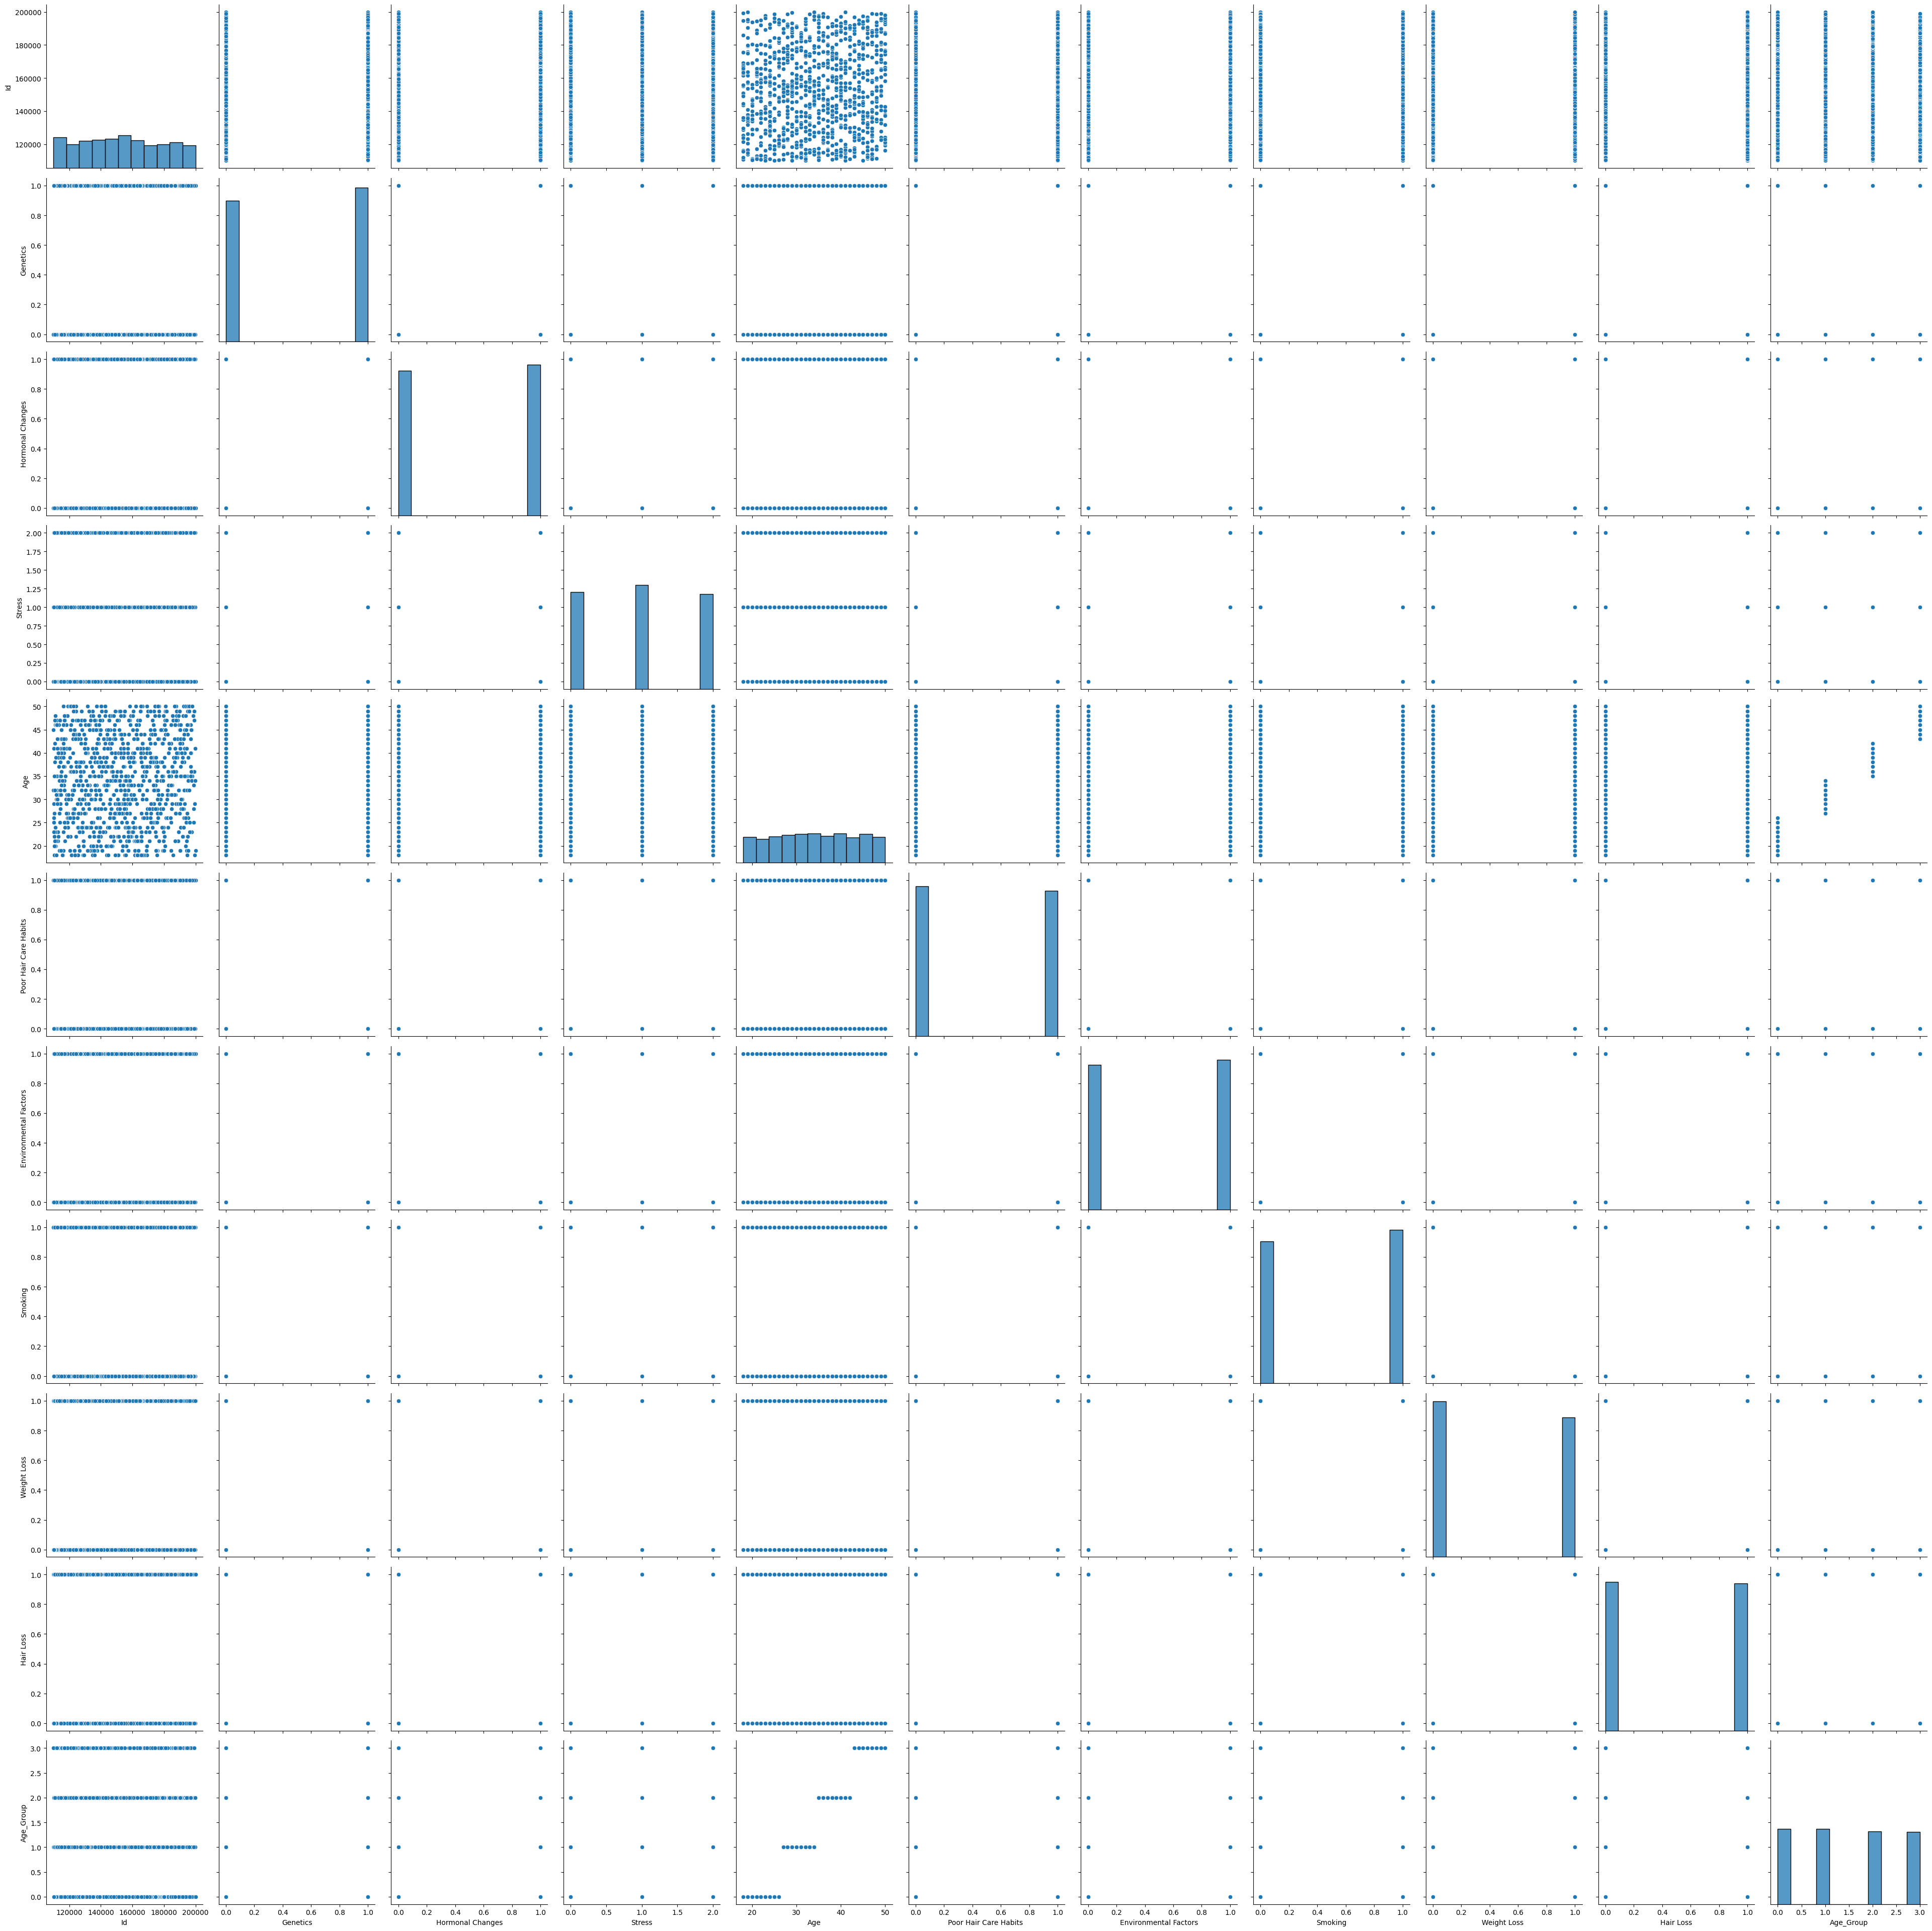

In [9]:
sns.pairplot(df, height=3.5)
plt.tight_layout()
plt.show()


Displaying the heatmap plot... Close the plot window to continue.


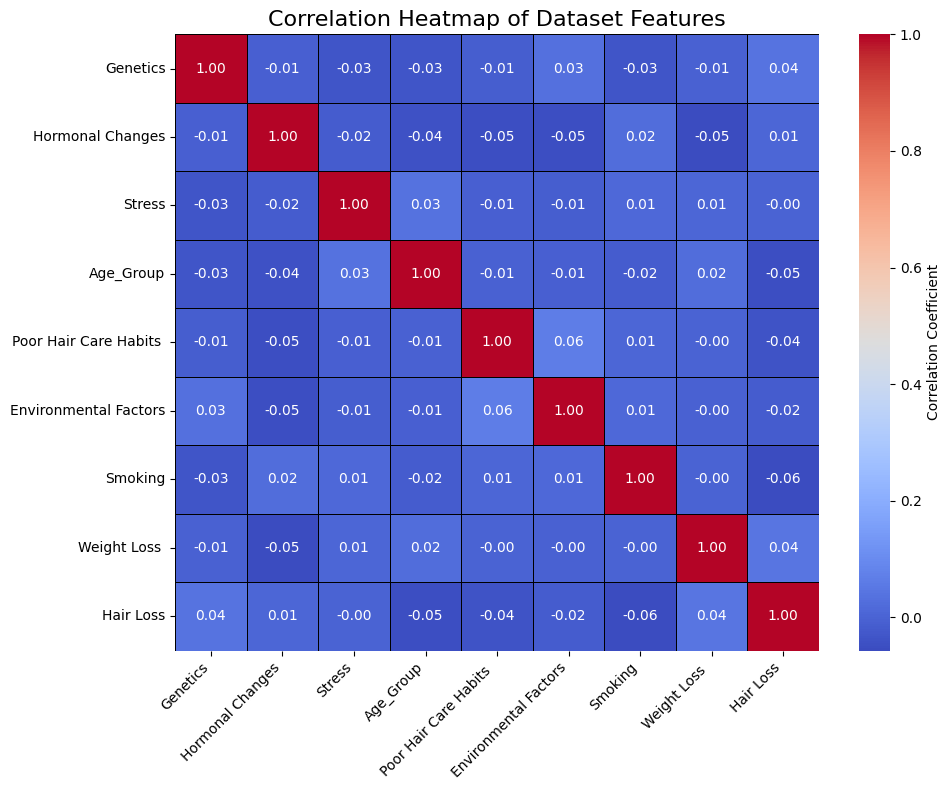

In [10]:
selected_features_for_heatmap = ['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Hair Loss']
correlation_matrix = df[selected_features_for_heatmap].corr()

plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Dataset Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
print("\nDisplaying the heatmap plot... Close the plot window to continue.")
plt.show()



In [11]:
# Define features and target
features = ['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Age',
           'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 
           'Weight Loss ', 'Medical Conditions', 'Medications & Treatments', 
           'Nutritional Deficiencies ']

X = df[features]
y = df['Hair Loss']

# First split: separate test set (10% of data)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Second split: divide remaining data into train and validation (89% train, 11% validation of remaining data)
# This will give us approximately 80-10-10 split of the total data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42
)

# Print the shapes of the resulting sets
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

# Calculate and print the percentages
total_samples = len(df)
print("\nData split percentages:")
print(f"Training: {len(X_train)/total_samples:.1%}")
print(f"Validation: {len(X_val)/total_samples:.1%}")
print(f"Test: {len(X_test)/total_samples:.1%}")

Training set shape: (799, 12)
Validation set shape: (100, 12)
Test set shape: (100, 12)

Data split percentages:
Training: 80.0%
Validation: 10.0%
Test: 10.0%


In [12]:
print(list(X_train.columns))

['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Age', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Medical Conditions', 'Medications & Treatments', 'Nutritional Deficiencies ']


In [21]:
y_train.value_counts(normalize=True)

Hair Loss
0    0.506884
1    0.493116
Name: proportion, dtype: float64

In [22]:
# Apply tree-based model
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score

import os
import platform

system_name = platform.system()
if system_name == "Darwin":
    os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib:' + os.environ.get('DYLD_LIBRARY_PATH', '')
    print("MacOS detected: OpenMP path set for XGBoost.")
else:
    print(f"ℹ️ Running on {system_name}, no OpenMP fix needed.")

from xgboost import XGBClassifier


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# One-Hot Encoding
# Consider Age_Group only instead of Age

# categorical_cols = ['Age_Group', 'Medical Conditions', 'Nutritional Deficiencies ', 'Medications & Treatments', 'Stress']

# print("Categorical columns:", categorical_cols)
# print("Numeric columns:", binary_cols)

# encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# encoder.fit(X_train[categorical_cols])


# OHE_train = pd.DataFrame(
#     encoder.transform(X_train[categorical_cols]),
#     columns=encoder.get_feature_names_out(categorical_cols)
# )
# OHE_test = pd.DataFrame(
#     encoder.transform(X_test[categorical_cols]),
#     columns=encoder.get_feature_names_out(categorical_cols)
# )

# X_train_final = X_train.drop(columns=categorical_cols).reset_index(drop=True)
# X_test_final = X_test.drop(columns=categorical_cols).reset_index(drop=True)

# X_train_final = pd.concat([X_train_final, OHE_train], axis=1)
# X_test_final = pd.concat([X_test_final, OHE_test], axis=1)

X_train_new, X_test_new, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train_new.shape)
print("Test set shape:", X_test_new.shape)


if 'Age_Group' in X_train_new.columns:
    X_train_final = X_train_new.drop(columns=['Age_Group'])
if 'Age_Group' in X_test_new.columns:
    X_test_final = X_test_new.drop(columns=['Age_Group'])

categorical_cols = ['Medical Conditions', 'Nutritional Deficiencies ', 'Medications & Treatments', 'Stress']
for col in categorical_cols:
    le = LabelEncoder()
    X_train_final[col] = le.fit_transform(X_train_final[col].astype(str))
    X_test_final[col] = le.transform(X_test_final[col].astype(str))

X_train_final.head()

MacOS detected: OpenMP path set for XGBoost.
Training set shape: (799, 12)
Test set shape: (200, 12)


,Genetics,Hormonal Changes,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Medical Conditions,Medications & Treatments,Nutritional Deficiencies
778,1,0,1,29,1,1,0,0,7,10,0
286,0,0,2,27,1,1,1,0,6,5,0
165,0,0,0,49,0,1,0,0,5,1,6
960,1,0,1,38,0,1,1,1,8,9,4
493,0,0,1,45,0,1,1,0,10,5,10


In [14]:
# Decision tree hyperparameter tuning

best_dt_auc = 0
best_dt_test_auc = 0
best_dt_acc = 0
best_dt_params = {}

from sklearn.model_selection import cross_val_score

for depth in [3, 5, 8, 10]:
    for min_split in [2, 5, 10]:
        for criterion in ['gini', 'entropy']:
            dt = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                criterion=criterion,
                random_state=42
            )
            # Cross-validation (5-fold) for AUC
            cv_auc = cross_val_score(dt, X_train_final, y_train_final, cv=5, scoring='roc_auc').mean()

            # Train once for accuracy on test set
            dt.fit(X_train_final, y_train_final)
            y_pred = dt.predict(X_test_final)
            y_prob = dt.predict_proba(X_test_final)[:, 1]
            test_auc = roc_auc_score(y_test_final, y_prob)
            acc = accuracy_score(y_test_final, y_pred)

            print(f"criterion={criterion}, max_depth={depth}, min_split={min_split} "
                  f"-> CV AUC: {cv_auc:.4f}, Test AUC: {test_auc:.4f}, Accuracy: {acc:.4f}")

            
            if cv_auc > best_dt_auc:
                best_dt_auc = cv_auc
                best_dt_test_auc = test_auc
                best_dt_acc = acc 
                best_dt_params = {
                    'criterion': criterion,
                    'max_depth': depth,
                    'min_samples_split': min_split
                }
                best_dt_model = dt

print("Best Decision Tree Params:", best_dt_params)
print("Best Cross-Validated AUC:", best_dt_auc)


print("Best Decision Tree Params:", best_dt_params)
print("Best Decision Tree AUC:", best_dt_auc)

criterion=gini, max_depth=3, min_split=2 -> CV AUC: 0.4924, Test AUC: 0.4532, Accuracy: 0.4250
criterion=entropy, max_depth=3, min_split=2 -> CV AUC: 0.4896, Test AUC: 0.4532, Accuracy: 0.4250
criterion=gini, max_depth=3, min_split=5 -> CV AUC: 0.4924, Test AUC: 0.4532, Accuracy: 0.4250
criterion=entropy, max_depth=3, min_split=5 -> CV AUC: 0.4896, Test AUC: 0.4532, Accuracy: 0.4250
criterion=gini, max_depth=3, min_split=10 -> CV AUC: 0.4905, Test AUC: 0.4618, Accuracy: 0.4300
criterion=entropy, max_depth=3, min_split=10 -> CV AUC: 0.4896, Test AUC: 0.4618, Accuracy: 0.4300
criterion=gini, max_depth=5, min_split=2 -> CV AUC: 0.4981, Test AUC: 0.4639, Accuracy: 0.4350
criterion=entropy, max_depth=5, min_split=2 -> CV AUC: 0.4861, Test AUC: 0.4639, Accuracy: 0.4350
criterion=gini, max_depth=5, min_split=5 -> CV AUC: 0.4973, Test AUC: 0.4639, Accuracy: 0.4350
criterion=entropy, max_depth=5, min_split=5 -> CV AUC: 0.4853, Test AUC: 0.4639, Accuracy: 0.4350
criterion=gini, max_depth=5, min_

In [15]:
# Random forest hyperparameter tuning

best_rf_auc = 0
best_rf_test_auc = 0
best_rf_acc = 0
best_rf_params = {}

n_estimators_list = [100, 200, 400]
max_depth_list = [3, 5, 8, 10]
criterion_list = ['gini', 'entropy']

for n in n_estimators_list:
    for depth in max_depth_list:
        for criterion in criterion_list:
            rf = RandomForestClassifier(
                n_estimators=n,
                max_depth=depth,
                criterion=criterion,
                random_state=42,
                n_jobs=-1
            )
           
            cv_auc = cross_val_score(rf, X_train_final, y_train_final, cv=5, scoring='roc_auc').mean()
            
            rf.fit(X_train_final, y_train_final)
            y_pred = rf.predict(X_test_final)
            y_prob = rf.predict_proba(X_test_final)[:, 1]
            test_auc = roc_auc_score(y_test_final, y_prob)
            acc = accuracy_score(y_test_final, y_pred)

            print(f"n_estimators={n}, max_depth={depth}, criterion={criterion} "
                  f"-> CV AUC: {cv_auc:.4f}, Test AUC: {test_auc:.4f}, Accuracy: {acc:.4f}")

            if cv_auc > best_rf_auc:
                best_rf_auc = cv_auc
                best_rf_test_auc = test_auc
                best_rf_acc = acc 
                best_rf_params = {
                    'n_estimators': n,
                    'max_depth': depth,
                    'criterion': criterion
                }
                best_rf_model = rf

print("\nBest Random Forest Params:", best_rf_params)
print("Best Cross-Validated AUC:", best_rf_auc)

n_estimators=100, max_depth=3, criterion=gini -> CV AUC: 0.4987, Test AUC: 0.5649, Accuracy: 0.5100
n_estimators=100, max_depth=3, criterion=entropy -> CV AUC: 0.5007, Test AUC: 0.5680, Accuracy: 0.5050
n_estimators=100, max_depth=5, criterion=gini -> CV AUC: 0.5118, Test AUC: 0.5573, Accuracy: 0.5100
n_estimators=100, max_depth=5, criterion=entropy -> CV AUC: 0.5077, Test AUC: 0.5542, Accuracy: 0.5050
n_estimators=100, max_depth=8, criterion=gini -> CV AUC: 0.5466, Test AUC: 0.5318, Accuracy: 0.4950
n_estimators=100, max_depth=8, criterion=entropy -> CV AUC: 0.5319, Test AUC: 0.5341, Accuracy: 0.5150
n_estimators=100, max_depth=10, criterion=gini -> CV AUC: 0.5405, Test AUC: 0.5342, Accuracy: 0.4750
n_estimators=100, max_depth=10, criterion=entropy -> CV AUC: 0.5299, Test AUC: 0.5297, Accuracy: 0.4950
n_estimators=200, max_depth=3, criterion=gini -> CV AUC: 0.5009, Test AUC: 0.5662, Accuracy: 0.5050
n_estimators=200, max_depth=3, criterion=entropy -> CV AUC: 0.4991, Test AUC: 0.5728, 

In [16]:
# XGBoost hyperparameter tuning

best_xgb_auc = 0
best_xgb_test_auc = 0
best_xgb_acc = 0
best_xgb_params = {}

eta_list = [0.01, 0.1, 0.2]
max_depth_list = [3, 5, 8]
n_estimators_list = [100, 200, 400]

for eta in eta_list:
    for depth in max_depth_list:
        for n in n_estimators_list:
            xgb = XGBClassifier(
                learning_rate=eta,
                max_depth=depth,
                n_estimators=n,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='logloss',  
                random_state=42,
                n_jobs=-1
            )
            cv_auc = cross_val_score(xgb, X_train_final, y_train_final, cv=5, scoring='roc_auc').mean()

            xgb.fit(X_train_final, y_train_final)
            y_pred = xgb.predict(X_test_final)
            y_prob = xgb.predict_proba(X_test_final)[:, 1]
            test_auc = roc_auc_score(y_test_final, y_prob)
            acc = accuracy_score(y_test_final, y_pred)

            print(f"eta={eta}, max_depth={depth}, n_estimators={n} "
                  f"-> CV AUC: {cv_auc:.4f}, Test AUC: {test_auc:.4f}, Accuracy: {acc:.4f}")

            if cv_auc > best_xgb_auc:
                best_xgb_auc = cv_auc
                best_xgb_test_auc = test_auc
                best_xgb_acc = acc 
                best_xgb_params = {
                    'learning_rate': eta,
                    'max_depth': depth,
                    'n_estimators': n
                }
                best_xgb_model = xgb

print("\nBest XGBoost Params:", best_xgb_params)
print("Best Cross-Validated AUC:", best_xgb_auc)


eta=0.01, max_depth=3, n_estimators=100 -> CV AUC: 0.5029, Test AUC: 0.5470, Accuracy: 0.5050
eta=0.01, max_depth=3, n_estimators=200 -> CV AUC: 0.5099, Test AUC: 0.5388, Accuracy: 0.5150
eta=0.01, max_depth=3, n_estimators=400 -> CV AUC: 0.5149, Test AUC: 0.5378, Accuracy: 0.4950
eta=0.01, max_depth=5, n_estimators=100 -> CV AUC: 0.5224, Test AUC: 0.5462, Accuracy: 0.4950
eta=0.01, max_depth=5, n_estimators=200 -> CV AUC: 0.5233, Test AUC: 0.5449, Accuracy: 0.5000
eta=0.01, max_depth=5, n_estimators=400 -> CV AUC: 0.5281, Test AUC: 0.5344, Accuracy: 0.5150
eta=0.01, max_depth=8, n_estimators=100 -> CV AUC: 0.5264, Test AUC: 0.5192, Accuracy: 0.4800
eta=0.01, max_depth=8, n_estimators=200 -> CV AUC: 0.5303, Test AUC: 0.5224, Accuracy: 0.5000
eta=0.01, max_depth=8, n_estimators=400 -> CV AUC: 0.5355, Test AUC: 0.5204, Accuracy: 0.4900
eta=0.1, max_depth=3, n_estimators=100 -> CV AUC: 0.5227, Test AUC: 0.5221, Accuracy: 0.5200
eta=0.1, max_depth=3, n_estimators=200 -> CV AUC: 0.5226, Tes

/var/folders/g8/69wcxg_92lg3nmk098fcdvdr0000gn/T/ipykernel_62774/2047742279.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


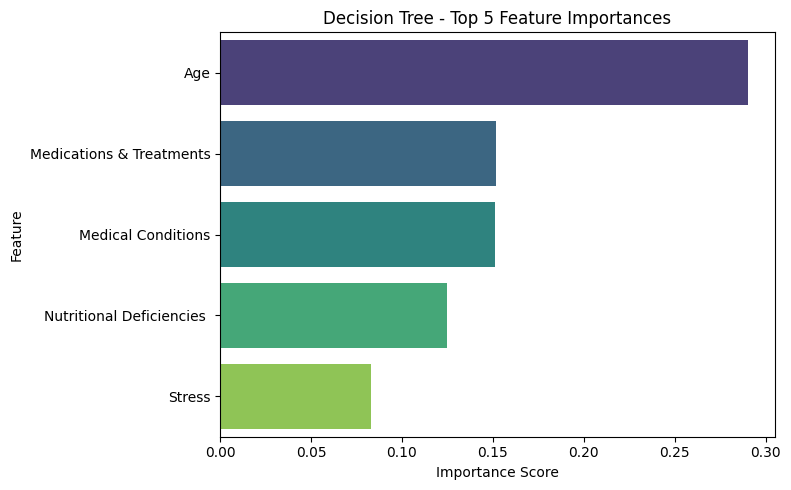

/var/folders/g8/69wcxg_92lg3nmk098fcdvdr0000gn/T/ipykernel_62774/2047742279.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


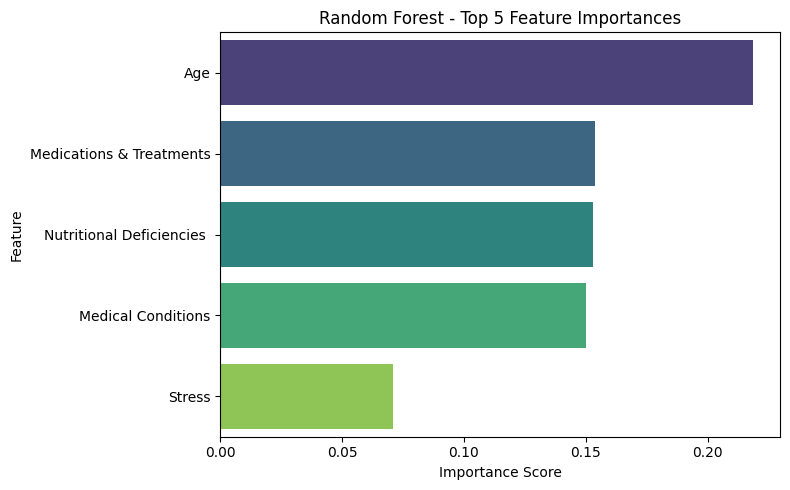

/var/folders/g8/69wcxg_92lg3nmk098fcdvdr0000gn/T/ipykernel_62774/2047742279.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


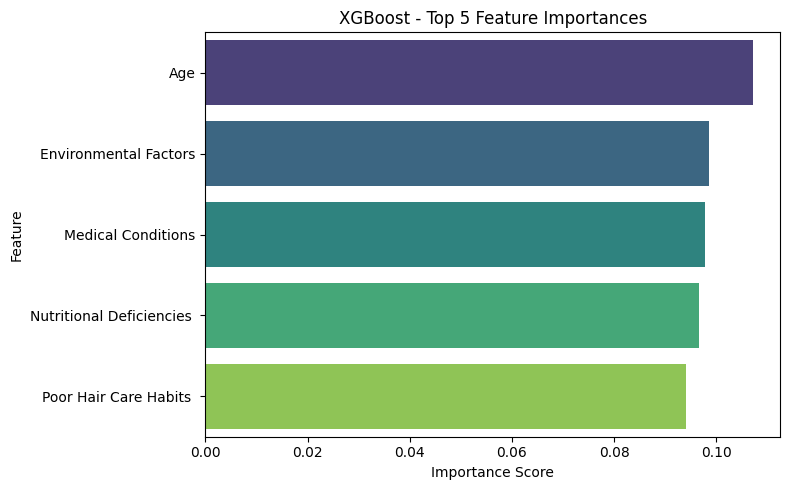

Decision Tree: ['Age', 'Medications & Treatments', 'Medical Conditions', 'Nutritional Deficiencies ', 'Stress']
Random Forest: ['Age', 'Medications & Treatments', 'Nutritional Deficiencies ', 'Medical Conditions', 'Stress']
XGBoost: ['Age', 'Environmental Factors', 'Medical Conditions', 'Nutritional Deficiencies ', 'Poor Hair Care Habits ']


In [17]:
# feature importance
models = {
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_xgb_model
}

top_features_map = {}

for name, model in models.items():
    
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        top_n = 5  
        
        top_features = np.array(X_train_final.columns)[indices[:top_n]].tolist()
        top_features_map[name] = top_features
        
        plt.figure(figsize=(8,5))
        sns.barplot(
            x=importances[indices[:top_n]],
            y=np.array(X_train_final.columns)[indices[:top_n]],
            palette="viridis"
        )
        plt.title(f"{name} - Top {top_n} Feature Importances")
        plt.xlabel("Importance Score")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

for model_name, feats in top_features_map.items():
    print(f"{model_name}: {feats}")


Decision Tree Performance:
AUC: 0.5255, Accuracy: 0.5350
              precision    recall  f1-score   support

           0       0.48      0.52      0.50        89
           1       0.59      0.55      0.57       111

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.54      0.54      0.54       200



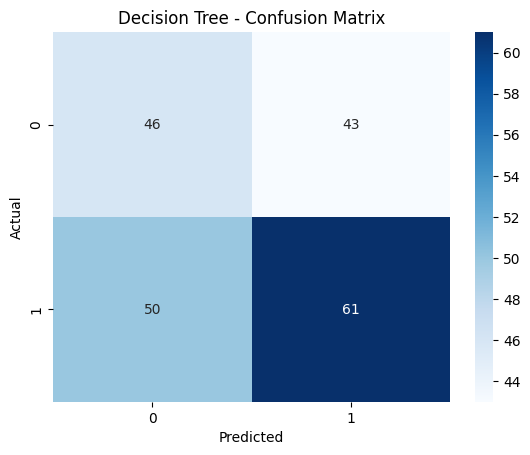

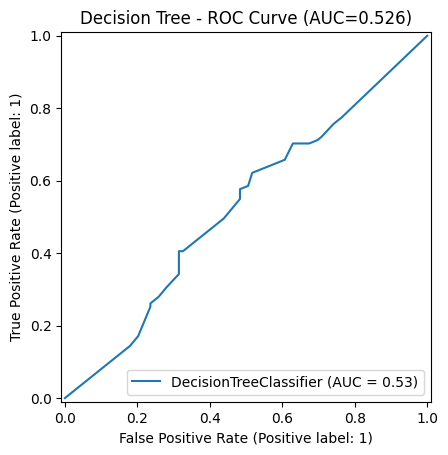


Random Forest Performance:
AUC: 0.5366, Accuracy: 0.4900
              precision    recall  f1-score   support

           0       0.45      0.64      0.53        89
           1       0.56      0.37      0.45       111

    accuracy                           0.49       200
   macro avg       0.51      0.50      0.49       200
weighted avg       0.51      0.49      0.48       200



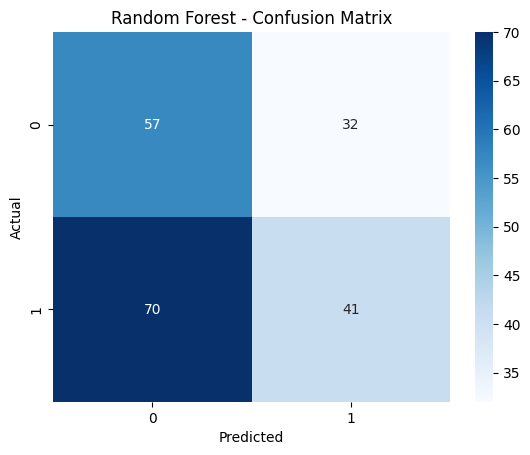

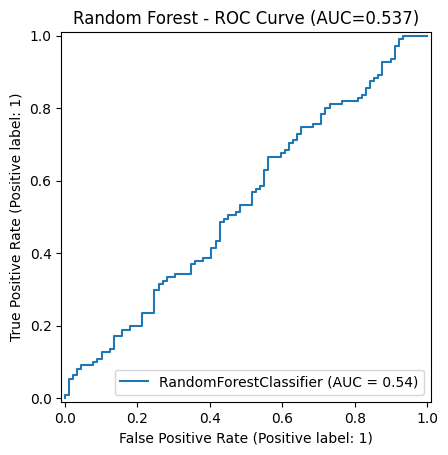


XGBoost Performance:
AUC: 0.5434, Accuracy: 0.5350
              precision    recall  f1-score   support

           0       0.48      0.66      0.56        89
           1       0.62      0.43      0.51       111

    accuracy                           0.54       200
   macro avg       0.55      0.55      0.53       200
weighted avg       0.56      0.54      0.53       200



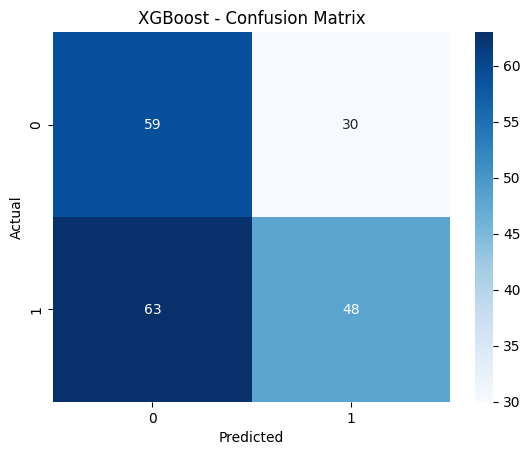

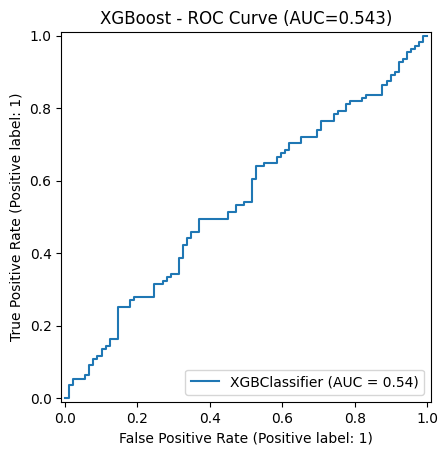

In [18]:
#confusion matrix + roc
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]
    auc = roc_auc_score(y_test_final, y_prob)
    acc = accuracy_score(y_test_final, y_pred)
    
    print(f"\n{name} Performance:")
    print(f"AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    print(classification_report(y_test_final, y_pred))
    
    # confusion matrix
    cm = confusion_matrix(y_test_final, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC curve
    RocCurveDisplay.from_estimator(model, X_test_final, y_test_final)
    plt.title(f"{name} - ROC Curve (AUC={auc:.3f})")
    plt.show()


In [19]:
# Cross-Validation Performance Summary:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'CV AUC (mean)': [best_dt_auc, best_rf_auc, best_xgb_auc],
    'Test AUC': [best_dt_test_auc, best_rf_test_auc, best_xgb_test_auc],
    'Test Accuracy': [best_dt_acc, best_rf_acc, best_xgb_acc]
})

results = results.sort_values(by='Test AUC', ascending=False).reset_index(drop=True)
display(results.style.format({
    "CV AUC (mean)": "{:.3f}",
    "Test AUC": "{:.3f}",
    "Test Accuracy": "{:.3f}"
}))

,Model,CV AUC (mean),Test AUC,Test Accuracy
0,XGBoost,0.546,0.543,0.535
1,Random Forest,0.548,0.537,0.490
2,Decision Tree,0.510,0.526,0.535


In [20]:
#refit it with top important feature

from sklearn.metrics import roc_auc_score, accuracy_score

refit_results = {}

for name, model in models.items():
    if name in top_features_map:
        selected_features = top_features_map[name]
        X_train_sel = X_train_final[selected_features]
        X_test_sel = X_test_final[selected_features]

        if name == "Decision Tree":
            params = best_dt_params
            refit_model = DecisionTreeClassifier(
                max_depth=params['max_depth'],
                min_samples_split=params['min_samples_split'],
                random_state=42
            )

        elif name == "Random Forest":
            params = best_rf_params
            refit_model = RandomForestClassifier(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                criterion =params['criterion'],
                random_state=42,
                n_jobs=-1
            )

        elif name == "XGBoost":
            params = best_xgb_params
            refit_model = XGBClassifier(
                learning_rate=params['learning_rate'],
                max_depth=params['max_depth'],
                n_estimators=params['n_estimators'],
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='logloss',
                random_state=42,
                n_jobs=-1
            )

        refit_model.fit(X_train_sel, y_train_final)
        y_pred = refit_model.predict(X_test_sel)
        y_prob = refit_model.predict_proba(X_test_sel)[:, 1]

        auc = roc_auc_score(y_test_final, y_prob)
        acc = accuracy_score(y_test_final, y_pred)

        refit_results[name] = {'AUC': auc, 'Accuracy': acc}

        print(f"\n{name} Refit with Top Features ({len(selected_features)} features):")
        print(f"Test AUC: {auc:.4f}, Accuracy: {acc:.4f}")

refit_df = pd.DataFrame(refit_results).T
display(refit_df.style.format({"AUC": "{:.3f}", "Accuracy": "{:.3f}"}))



Decision Tree Refit with Top Features (5 features):
Test AUC: 0.4941, Accuracy: 0.5050

Random Forest Refit with Top Features (5 features):
Test AUC: 0.5076, Accuracy: 0.4900

XGBoost Refit with Top Features (5 features):
Test AUC: 0.5265, Accuracy: 0.5400


,AUC,Accuracy
Decision Tree,0.494,0.505
Random Forest,0.508,0.490
XGBoost,0.527,0.540
